# 28 — Simulation Mode Validation

> **Verify qubox simulation mode with all hardware outputs off.**

## Purpose

Validate that qubox's default simulation mode works end-to-end: the session opens without
activating RF outputs, `run_program()` is correctly blocked, and QM waveform simulation via
`experiment.simulate()` produces valid pulse data. This runs with the device off — only the
QM compiler/simulator backend on the hosted server is used.

## Methodology

1. **Server reachability check** — verify the QM server at `10.157.36.68` responds before attempting connection
2. **Session open** — `simulation_mode=True` is the default; skips `hardware.open_qm()`, no RF outputs enabled
3. **ExecMode verification** — confirm the runner is locked to `ExecMode.SIMULATE` and `run_program()` raises `JobError`
4. **Low-power resonator spectroscopy simulation** — build and simulate a minimal resonator sweep (n_avg=1, narrow window)
5. **Waveform inspection** — verify simulated analog/digital samples contain valid pulse data

## Prerequisites

- Notebook 00 must have been run at least once to create the sample registry and cooldown config
- The QM server at `10.157.36.68` must be reachable (compilation/simulation is server-side)
- **No hardware required** — the OPX+ and Octave can be powered off

## 1. Import qubox and Check Server Reachability

Import the qubox notebook surface and verify the QM server is reachable before attempting
to open a session. Simulation mode still requires the QMM connection for server-side
compilation — if the server is unreachable, we stop immediately (§15.3).

In [4]:
import sys
import subprocess
from pathlib import Path

sys.path.insert(0, r"E:\qubox")

# §15.3 — Check server reachability before attempting QMM connection
QOP_IP = "10.157.36.68"
CLUSTER_NAME = "Cluster_2"

ping_result = subprocess.run(
    ["ping", "-n", "1", "-w", "3000", QOP_IP],
    capture_output=True, text=True,
)
server_reachable = ping_result.returncode == 0
print(f"QM server {QOP_IP}: {'REACHABLE' if server_reachable else 'UNREACHABLE'}")
if not server_reachable:
    raise ConnectionError(
        f"QM server at {QOP_IP} is not responding. "
        f"Simulation mode requires the server for compilation. Cannot proceed."
    )

QM server 10.157.36.68: REACHABLE


## 2. Open Session (Simulation Mode — Default)

Open a shared session. `simulation_mode=True` is the default, so no explicit flag is needed:
- Creates the `QuantumMachinesManager` connection (needed for `qmm.simulate()`)
- **Skips** `hardware.open_qm()` — no `QuantumMachine` instance, no RF outputs
- Locks the runner to `ExecMode.SIMULATE` — `run_program()` raises `JobError`

In [ ]:
from qubox.notebook import (
    ResonatorSpectroscopy,
    open_shared_session,
    get_shared_session,
    close_shared_session,
)
from qubox.hardware.program_runner import QuboxSimulationConfig, ExecMode
from qubox.core.errors import JobError

REGISTRY_BASE = Path(r"E:\qubox")
SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2026_03_24"

# Close any existing session from prior notebooks
existing = get_shared_session()
if existing is not None:
    close_shared_session()
    print("Closed existing shared session.")

# Open session — simulation_mode=True is now the default (no RF outputs)
session = open_shared_session(
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    registry_base=REGISTRY_BASE,
    qop_ip=QOP_IP,
    cluster_name=CLUSTER_NAME,
    auto_save_calibration=False,
    force_reopen=True,
)

print(f"\nSession opened successfully")
print(f"  simulation_mode: {session.simulation_mode}")
print(f"  runner exec_mode: {session.runner.exec_mode}")
print(f"  hardware.qm is None: {session.hardware.qm is None}")

Closed existing shared session.
2026-04-01 00:22:19,221 - qm - INFO     - Performing health check
2026-04-01 00:22:19,225 - qm - INFO     - Health check passed

Session opened successfully
  simulation_mode: True
  runner exec_mode: ExecMode.SIMULATE
  hardware.qm is None: True


C:\Users\jl82323\AppData\Local\Temp\ipykernel_34212\2196313512.py:33: DeprecationWarning: Session.simulation_mode is forwarded to the legacy SessionManager. Use Session's own API or access Session.legacy_session.simulation_mode explicitly. This forwarding will be removed in a future version.
  print(f"  simulation_mode: {session.simulation_mode}")
C:\Users\jl82323\AppData\Local\Temp\ipykernel_34212\2196313512.py:34: DeprecationWarning: Session.runner is forwarded to the legacy SessionManager. Use Session's own API or access Session.legacy_session.runner explicitly. This forwarding will be removed in a future version.
  print(f"  runner exec_mode: {session.runner.exec_mode}")
C:\Users\jl82323\AppData\Local\Temp\ipykernel_34212\2196313512.py:35: DeprecationWarning: Session.hardware is forwarded to the legacy SessionManager. Use Session's own API or access Session.legacy_session.hardware explicitly. This forwarding will be removed in a future version.
  print(f"  hardware.qm is None: {ses

## 3. Verify ExecMode Guards

Confirm the safety guards are working:
- `runner.exec_mode` must be `ExecMode.SIMULATE`
- `runner.run_program()` must raise `JobError` (hardware execution blocked)
- `session.simulation_mode` property must return `True`

In [6]:
# --- Verify ExecMode ---
assert session.simulation_mode is True, "simulation_mode should be True"
assert session.runner.exec_mode == ExecMode.SIMULATE, (
    f"Expected ExecMode.SIMULATE, got {session.runner.exec_mode}"
)
print("PASS: session.simulation_mode is True")
print(f"PASS: runner.exec_mode is {session.runner.exec_mode}")

# --- Verify run_program() is blocked ---
run_blocked = False
try:
    session.runner.run_program(None, n_total=1)
except JobError as e:
    run_blocked = True
    print(f"PASS: run_program() correctly blocked with JobError")
    print(f"  Message: {e}")
except Exception as e:
    run_blocked = True
    print(f"PASS: run_program() blocked (raised {type(e).__name__}: {e})")

assert run_blocked, "run_program() should have raised an error in simulation mode"
print("\nAll ExecMode guards verified.")

PASS: session.simulation_mode is True
PASS: runner.exec_mode is ExecMode.SIMULATE
PASS: run_program() correctly blocked with JobError
  Message: run_program() is hardware-only, but ProgramRunner is in ExecMode.SIMULATE. Call set_exec_mode('hardware') or use simulate().

All ExecMode guards verified.


C:\Users\jl82323\AppData\Local\Temp\ipykernel_34212\4007602227.py:2: DeprecationWarning: Session.simulation_mode is forwarded to the legacy SessionManager. Use Session's own API or access Session.legacy_session.simulation_mode explicitly. This forwarding will be removed in a future version.
  assert session.simulation_mode is True, "simulation_mode should be True"
C:\Users\jl82323\AppData\Local\Temp\ipykernel_34212\4007602227.py:3: DeprecationWarning: Session.runner is forwarded to the legacy SessionManager. Use Session's own API or access Session.legacy_session.runner explicitly. This forwarding will be removed in a future version.
  assert session.runner.exec_mode == ExecMode.SIMULATE, (
C:\Users\jl82323\AppData\Local\Temp\ipykernel_34212\4007602227.py:7: DeprecationWarning: Session.runner is forwarded to the legacy SessionManager. Use Session's own API or access Session.legacy_session.runner explicitly. This forwarding will be removed in a future version.
  print(f"PASS: runner.exec

## 4. Run Low-Power Resonator Spectroscopy Simulation

Build a minimal resonator spectroscopy program and simulate it via the QM server.
Using validation shortcuts per §6:
- `n_avg=1` — minimum averaging
- Narrow frequency window (±2 MHz) — fast compilation
- Shortened thermalization (100 clks) — structural check only
- Short simulation duration (4000 ns) — minimum to see pulse sequence

In [7]:
import numpy as np

# Get current runtime parameters
attr = session.context_snapshot()
ro_fq = float(attr.ro_fq)
ro_therm_clks = int(getattr(attr, "ro_therm_clks", 1000) or 1000)

print(f"Runtime readout frequency: {ro_fq / 1e9:.6f} GHz")
print(f"Readout thermalization: {ro_therm_clks} clks")

# Low-power simulation parameters
SIM_N_AVG = 1
SIM_SPAN_HZ = 4e6
SIM_DF = 1e6
SIM_DURATION_NS = 4000
SIM_RO_THERM_CLKS = 100

rf_begin = int(ro_fq - SIM_SPAN_HZ / 2)
rf_end = int(ro_fq + SIM_SPAN_HZ / 2)

print(f"\nSimulation parameters:")
print(f"  n_avg: {SIM_N_AVG}")
print(f"  rf_begin: {rf_begin / 1e9:.6f} GHz")
print(f"  rf_end: {rf_end / 1e9:.6f} GHz")
print(f"  df: {SIM_DF / 1e3:.0f} kHz")
print(f"  duration: {SIM_DURATION_NS} ns")
print(f"  ro_therm_clks: {SIM_RO_THERM_CLKS} (shortened for sim)")

Runtime readout frequency: 8.596223 GHz
Readout thermalization: 1000 clks

Simulation parameters:
  n_avg: 1
  rf_begin: 8.594223 GHz
  rf_end: 8.598223 GHz
  df: 1000 kHz
  duration: 4000 ns
  ro_therm_clks: 100 (shortened for sim)


C:\Users\jl82323\AppData\Local\Temp\ipykernel_34212\1870843853.py:4: DeprecationWarning: Session.context_snapshot is forwarded to the legacy SessionManager. Use Session's own API or access Session.legacy_session.context_snapshot explicitly. This forwarding will be removed in a future version.
  attr = session.context_snapshot()


Building QUA program and running simulation on QM server...
  Server: 10.157.36.68 (Cluster_2)
  Duration: 4000 ns (1000 clock cycles)
2026-04-01 00:22:19,706 - qm - INFO     - Simulating program


c:\Python312\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


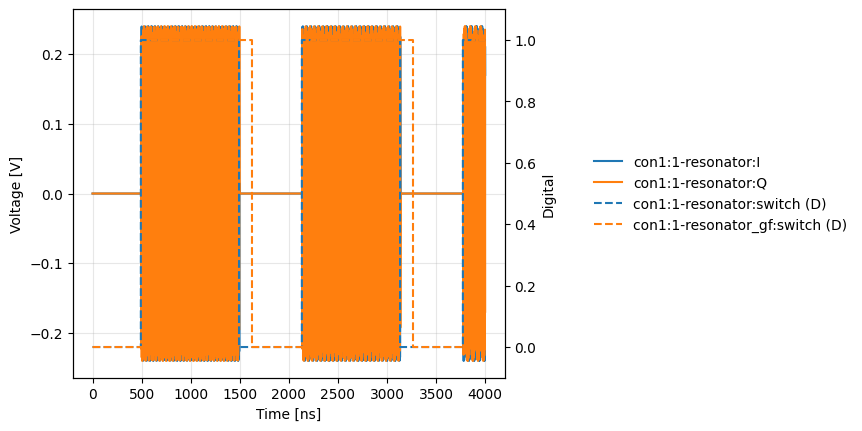


Simulation completed successfully!
  Result type: SimulationResult
  Duration simulated: 4000 ns


In [8]:
resonator_spec = ResonatorSpectroscopy(session)

sim_config = QuboxSimulationConfig(
    duration_ns=SIM_DURATION_NS,
    plot=True,
    controllers=("con1",),
)

print("Building QUA program and running simulation on QM server...")
print(f"  Server: {QOP_IP} ({CLUSTER_NAME})")
print(f"  Duration: {SIM_DURATION_NS} ns ({SIM_DURATION_NS // 4} clock cycles)")

sim_result = resonator_spec.simulate(
    sim_config=sim_config,
    readout_op="readout",
    rf_begin=rf_begin,
    rf_end=rf_end,
    df=SIM_DF,
    n_avg=SIM_N_AVG,
    ro_therm_clks=SIM_RO_THERM_CLKS,
)

print("\nSimulation completed successfully!")
print(f"  Result type: {type(sim_result).__name__}")
print(f"  Duration simulated: {sim_result.duration_ns} ns")

## 5. Inspect Simulation Results — Waveform Samples

Examine the simulated analog and digital waveform samples returned by the QM simulator.
These represent the actual pulse sequences that **would** be sent to the OPX+ DACs and
digital outputs. The element-to-channel relabeling shows named elements
(e.g., `resonator:I`, `resonator:Q`) instead of raw port numbers.

In [9]:
samples = sim_result.samples

print("Simulated controller outputs:")
print(f"  Controllers: {list(samples.keys())}")

for ctrl_name, ctrl_samples in samples.items():
    print(f"\n[{ctrl_name}]")

    # Analog channels
    print(f"  Analog channels ({len(ctrl_samples.analog)}):")
    for ch_name, waveform in ctrl_samples.analog.items():
        arr = np.asarray(waveform)
        nonzero = np.count_nonzero(arr)
        peak = np.max(np.abs(arr)) if arr.size > 0 else 0
        print(f"    {ch_name}: {arr.size} samples, {nonzero} nonzero, peak={peak:.4f}")

    # Digital channels
    print(f"  Digital channels ({len(ctrl_samples.digital)}):")
    for ch_name, waveform in ctrl_samples.digital.items():
        arr = np.asarray(waveform)
        high_count = np.count_nonzero(arr)
        print(f"    {ch_name}: {arr.size} samples, {high_count} high")

Simulated controller outputs:
  Controllers: ['con1']

[con1]
  Analog channels (10):
    1-resonator:I: 4000 samples, 2224 nonzero, peak=0.2400
    1-resonator:Q: 4000 samples, 2224 nonzero, peak=0.2400
    1-resonator_gf:I: 4000 samples, 0 nonzero, peak=0.0000
    1-resonator_gf:Q: 4000 samples, 0 nonzero, peak=0.0000
    1-transmon:I: 4000 samples, 0 nonzero, peak=0.0000
    1-transmon:Q: 4000 samples, 0 nonzero, peak=0.0000
    1-storage_gf:I: 4000 samples, 0 nonzero, peak=0.0000
    1-storage_gf:Q: 4000 samples, 0 nonzero, peak=0.0000
    1-storage:I: 4000 samples, 0 nonzero, peak=0.0000
    1-storage:Q: 4000 samples, 0 nonzero, peak=0.0000
  Digital channels (2):
    1-resonator:switch: 4000 samples, 2228 high
    1-resonator_gf:switch: 4000 samples, 2204 high


## 6. Validate Correctness — Pulse Structure Verification

Verify the simulation produced physically correct output:
1. At least one analog channel has nonzero data (readout pulse was emitted)
2. Digital switch activity is present
3. Build provenance chain is intact (program metadata, config snapshot)
4. Config snapshot captured all expected elements

In [10]:
# --- Validation 1: Analog channels have pulse data ---
has_analog_data = False
readout_channels = {}
for ctrl_name, ctrl_samples in samples.items():
    for ch_name, waveform in ctrl_samples.analog.items():
        arr = np.asarray(waveform)
        if np.count_nonzero(arr) > 0:
            has_analog_data = True
            if "resonator" in ch_name.lower():
                readout_channels[ch_name] = arr

assert has_analog_data, "No analog channels have nonzero data — simulation produced no pulses"
print(f"PASS: Found nonzero analog data in simulated output")
print(f"  Readout channels identified: {list(readout_channels.keys())}")

# --- Validation 2: Digital switch triggered ---
has_digital_activity = False
for ctrl_name, ctrl_samples in samples.items():
    for ch_name, waveform in ctrl_samples.digital.items():
        arr = np.asarray(waveform)
        if np.count_nonzero(arr) > 0:
            has_digital_activity = True
            break

if has_digital_activity:
    print("PASS: Digital switch activity detected")
else:
    print("WARN: No digital activity (may be expected depending on switch config)")

# --- Validation 3: Build provenance chain ---
build = sim_result.build
assert build is not None, "SimulationResult.build should not be None"
assert build.program is not None, "Build should contain a QUA program"
assert build.experiment_name == "ResonatorSpectroscopy", (
    f"Expected 'ResonatorSpectroscopy', got '{build.experiment_name}'"
)
print(f"PASS: Build provenance intact — experiment={build.experiment_name}")
print(f"  Builder: {build.builder_function}")
print(f"  Params: n_avg={build.params.get('n_avg')}, df={build.params.get('df')}")

# --- Validation 4: Config snapshot captured ---
assert sim_result.config_snapshot is not None, "Config snapshot should be captured"
elements = list(sim_result.config_snapshot.get("elements", {}).keys())
print(f"PASS: Config snapshot has {len(elements)} elements: {elements}")

# --- Summary ---
print("\n" + "=" * 60)
print("SIMULATION MODE VALIDATION: ALL CHECKS PASSED")
print("=" * 60)
print(f"  Session mode:    simulation_mode=True")
print(f"  RF outputs:      OFF (hardware.qm is None)")
print(f"  run_program():   BLOCKED (JobError)")
print(f"  simulate():      WORKING")
print(f"  Pulse data:      VALID (nonzero analog waveforms)")
print(f"  Provenance:      INTACT (build + config snapshot)")

PASS: Found nonzero analog data in simulated output
  Readout channels identified: ['1-resonator:I', '1-resonator:Q']
PASS: Digital switch activity detected
PASS: Build provenance intact — experiment=ResonatorSpectroscopy
  Builder: cQED_programs.resonator_spectroscopy
  Params: n_avg=1, df=1000000.0
PASS: Config snapshot has 5 elements: ['resonator', 'transmon', 'storage', 'storage_gf', 'resonator_gf']

SIMULATION MODE VALIDATION: ALL CHECKS PASSED
  Session mode:    simulation_mode=True
  RF outputs:      OFF (hardware.qm is None)
  run_program():   BLOCKED (JobError)
  simulate():      WORKING
  Pulse data:      VALID (nonzero analog waveforms)
  Provenance:      INTACT (build + config snapshot)


In [11]:
# Clean up — close the simulation session
close_shared_session()
print("Simulation session closed.")

Simulation session closed.
